<a href="https://colab.research.google.com/github/rodrigoviannasn/MAT-422/blob/main/MAT422_HW_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT 422 — Homework 2.2: Probability and Random Variables

Rodrigo Vianna | 9/20/2026

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(422)
np.set_printoptions(precision=4, suppress=True)

## 2.2.1 Probability Axioms
Probability assigns a number between 0 and 1 to an event. The probability axioms state that:

1. $P(E) \geq 0$ for every event \(E\).
2. $P(\Omega)=1$, where $\Omega$ is the sample space.
3. If two events are disjoint, then

$$
P(A \cup B)=P(A)+P(B).
$$

For this example, the sample space consists of twelve equally likely numbered outcomes.

In [24]:
sample_space = set(range(1, 13))

def probability(event, omega):
    return len(event) / len(omega)

even_numbers = {2, 4, 6, 8, 10, 12}
not_even_numbers = sample_space - even_numbers

event_c = {1, 2, 3, 4}
event_d = {9, 10, 11, 12}

print("Sample space Ω:", sorted(sample_space))
print("\nP(Ω) =", probability(sample_space, sample_space))
print("P(empty set) =", probability(set(), sample_space))

print("\nP(even numbers) =", probability(even_numbers, sample_space))
print("P(not even numbers) =", probability(not_even_numbers, sample_space))
print("P(even) + P(not even) =",
      probability(even_numbers, sample_space) +
      probability(not_even_numbers, sample_space))

print("\nEvents C and D are disjoint:", event_c.isdisjoint(event_d))
print("P(C ∪ D) =", probability(event_c | event_d, sample_space))
print("P(C) + P(D) =",
      probability(event_c, sample_space) +
      probability(event_d, sample_space))

Sample space Ω: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

P(Ω) = 1.0
P(empty set) = 0.0

P(even numbers) = 0.5
P(not even numbers) = 0.5
P(even) + P(not even) = 1.0

Events C and D are disjoint: True
P(C ∪ D) = 0.6666666666666666
P(C) + P(D) = 0.6666666666666666


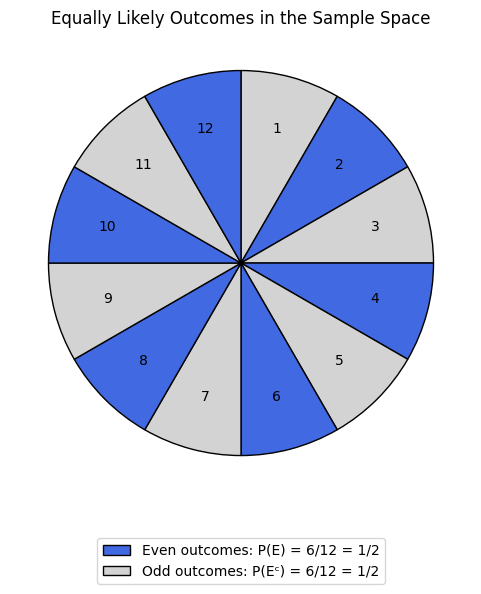

In [25]:
from matplotlib.patches import Wedge, Patch

fig, ax = plt.subplots(figsize=(6, 6))

number_of_outcomes = 12
angle_per_outcome = 360 / number_of_outcomes

for index, outcome in enumerate(range(1, 13)):
    theta_1 = 90 - (index + 1) * angle_per_outcome
    theta_2 = 90 - index * angle_per_outcome

    color = "royalblue" if outcome in even_numbers else "lightgray"

    wedge = Wedge(
        center=(0, 0),
        r=1,
        theta1=theta_1,
        theta2=theta_2,
        facecolor=color,
        edgecolor="black"
    )

    ax.add_patch(wedge)

    middle_angle = np.radians((theta_1 + theta_2) / 2)
    ax.text(
        0.72 * np.cos(middle_angle),
        0.72 * np.sin(middle_angle),
        str(outcome),
        ha="center",
        va="center"
    )

legend_items = [
    Patch(facecolor="royalblue", edgecolor="black",
          label="Even outcomes: P(E) = 6/12 = 1/2"),
    Patch(facecolor="lightgray", edgecolor="black",
          label="Odd outcomes: P(Eᶜ) = 6/12 = 1/2")
]

ax.legend(handles=legend_items, loc="upper center",
          bbox_to_anchor=(0.5, -0.08))

ax.set_title("Equally Likely Outcomes in the Sample Space")
ax.set_aspect("equal")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axis("off")

plt.show()

### Section Reflection

This example showed that probabilities must be nonnegative, the full sample space has probability 1, and the empty set has probability 0. The even and odd outcomes were complements, so their probabilities added to 1. The disjoint events also verified the addition rule because the probability of their union equaled the sum of their separate probabilities.

## 2.2.2 Conditional Probability
Conditional probability measures the probability of event \(A\) after knowing that event \(B\) has occurred.

$$
P(A \mid B)=\frac{P(A \cap B)}{P(B)},
$$

as long as \(P(B)>0\).

In this example, two fair dice are rolled. Event \(A\) is that the sum is at least 9, and event \(B\) is that the first die shows an even number.

In [26]:
dice_outcomes = {(die_1, die_2)
                 for die_1 in range(1, 7)
                 for die_2 in range(1, 7)}

event_a = {outcome for outcome in dice_outcomes
           if sum(outcome) >= 9}

event_b = {outcome for outcome in dice_outcomes
           if outcome[0] % 2 == 0}

intersection = event_a & event_b

p_a = probability(event_a, dice_outcomes)
p_b = probability(event_b, dice_outcomes)
p_a_and_b = probability(intersection, dice_outcomes)
p_a_given_b = p_a_and_b / p_b

print("Number of possible dice outcomes:", len(dice_outcomes))
print("P(A): sum is at least 9 =", p_a)
print("P(B): first die is even =", p_b)
print("P(A ∩ B) =", p_a_and_b)
print("P(A | B) =", p_a_given_b)

print("\nCheck multiplication rule:")
print("P(A | B) × P(B) =", p_a_given_b * p_b)
print("Does this equal P(A ∩ B)?",
      np.isclose(p_a_given_b * p_b, p_a_and_b))

Number of possible dice outcomes: 36
P(A): sum is at least 9 = 0.2777777777777778
P(B): first die is even = 0.5
P(A ∩ B) = 0.16666666666666666
P(A | B) = 0.3333333333333333

Check multiplication rule:
P(A | B) × P(B) = 0.16666666666666666
Does this equal P(A ∩ B)? True


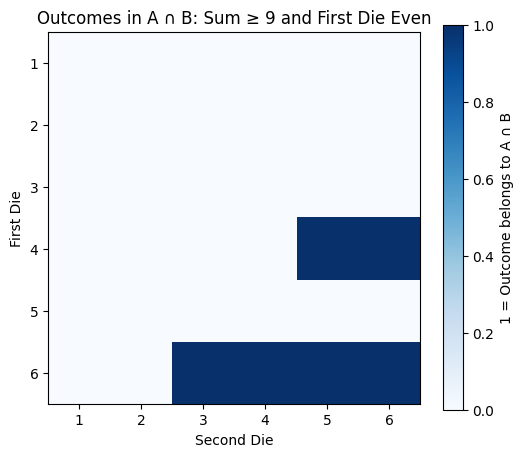

In [27]:
die_values = np.arange(1, 7)
sum_grid = np.add.outer(die_values, die_values)

intersection_grid = (
    (sum_grid >= 9) &
    (die_values[:, None] % 2 == 0)
)

plt.figure(figsize=(6, 5))
plt.imshow(intersection_grid.astype(int), cmap="Blues", vmin=0, vmax=1)

plt.xticks(range(6), die_values)
plt.yticks(range(6), die_values)
plt.xlabel("Second Die")
plt.ylabel("First Die")
plt.title("Outcomes in A ∩ B: Sum ≥ 9 and First Die Even")
plt.colorbar(label="1 = Outcome belongs to A ∩ B")
plt.show()

### Section Reflection

Conditional probability changed the probability of a large dice sum because additional information was provided. Knowing that the first die was even changed the probability of obtaining a sum of at least 9 to $P(A \mid B=\frac{1}{3})$. The multiplication rule also confirmed that $P(A \cap B)=P(A \mid B)P(B)$.

## 2.2.3 Discrete Random Variables
A discrete random variable has a finite or countably infinite collection of possible values.

Let \(X\) represent the number of heads obtained when three fair coins are flipped. The possible values are

$$
X \in \{0,1,2,3\}.
$$

The probability mass function, or PMF, gives the probability of each possible value of \(X\).

In [28]:
x_values = np.array([0, 1, 2, 3])
pmf = np.array([1, 3, 3, 1]) / 8

expected_value = np.sum(x_values * pmf)
variance = np.sum((x_values - expected_value)**2 * pmf)

print("Possible values of X:", x_values)
print("Probability mass function:", pmf)
print("Sum of PMF probabilities:", np.sum(pmf))

print("\nExpected value E[X]:", expected_value)
print("Variance Var(X):", variance)

# Simulate the number of heads in three fair coin flips
simulated_x = rng.binomial(n=3, p=0.5, size=10000)

print("\nSimulated mean:", np.mean(simulated_x))
print("Simulated variance:", np.var(simulated_x))

Possible values of X: [0 1 2 3]
Probability mass function: [0.125 0.375 0.375 0.125]
Sum of PMF probabilities: 1.0

Expected value E[X]: 1.5
Variance Var(X): 0.75

Simulated mean: 1.499
Simulated variance: 0.747999


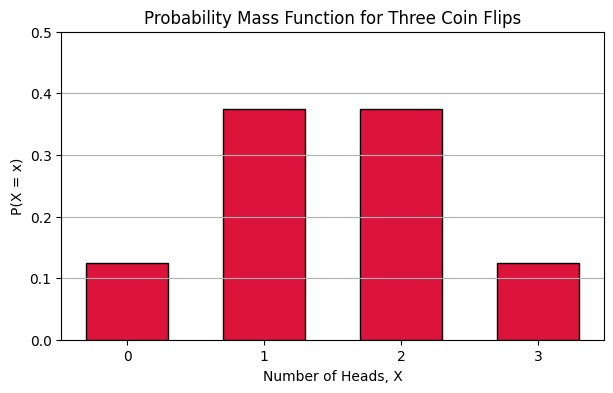

In [29]:
plt.figure(figsize=(7, 4))
plt.bar(x_values, pmf, color="crimson", edgecolor="black", width=0.6)

plt.xlabel("Number of Heads, X")
plt.ylabel("P(X = x)")
plt.title("Probability Mass Function for Three Coin Flips")
plt.xticks(x_values)
plt.ylim(0, 0.5)
plt.grid(axis="y")
plt.show()

### Section Reflection

The random variable \(X\), which counted heads in three coin flips, had four possible values. Its PMF showed that one or two heads were more likely than zero or three heads. The theoretical expected value was 1.5 heads, and the simulated mean and variance were close to the theoretical values, which demonstrated how repeated random trials approach expected probability results.

## 2.2.4 Continuous Random Variables
A continuous random variable can take any value within an interval. Instead of a PMF, it is described by a probability density function, or PDF.

For this example, let \(Y\) follow a uniform distribution from 2 to 8:

$$
Y \sim \operatorname{Uniform}(2,8).
$$

The density is constant between 2 and 8:

$$
f(y)=\frac{1}{8-2}=\frac{1}{6}.
$$

The probability of an interval is the area under the PDF. For example,

$$
P(3 \leq Y \leq 5)=\int_3^5 f(y)\,dy.
$$

In [30]:
lower_bound = 2
upper_bound = 8

def uniform_pdf(x, a, b):
    return np.where((x >= a) & (x <= b), 1 / (b - a), 0)

x_range = np.linspace(0, 10, 1000)
pdf_values = uniform_pdf(x_range, lower_bound, upper_bound)

interval_lower = 3
interval_upper = 5

exact_probability = (
    (interval_upper - interval_lower) /
    (upper_bound - lower_bound)
)

x_interval = np.linspace(interval_lower, interval_upper, 1000)
numerical_probability = np.trapezoid(
    uniform_pdf(x_interval, lower_bound, upper_bound),
    x_interval
)

continuous_samples = rng.uniform(lower_bound, upper_bound, size=10000)
simulated_probability = np.mean(
    (continuous_samples >= interval_lower) &
    (continuous_samples <= interval_upper)
)

print("Exact P(3 ≤ Y ≤ 5):", exact_probability)
print("Area under PDF from 3 to 5:", numerical_probability)
print("Simulated P(3 ≤ Y ≤ 5):", simulated_probability)

print("\nTheoretical mean:", (lower_bound + upper_bound) / 2)
print("Theoretical variance:", (upper_bound - lower_bound)**2 / 12)

print("\nFor a continuous random variable:")
print("P(Y = 4) = 0")

Exact P(3 ≤ Y ≤ 5): 0.3333333333333333
Area under PDF from 3 to 5: 0.33333333333333337
Simulated P(3 ≤ Y ≤ 5): 0.3343

Theoretical mean: 5.0
Theoretical variance: 3.0

For a continuous random variable:
P(Y = 4) = 0


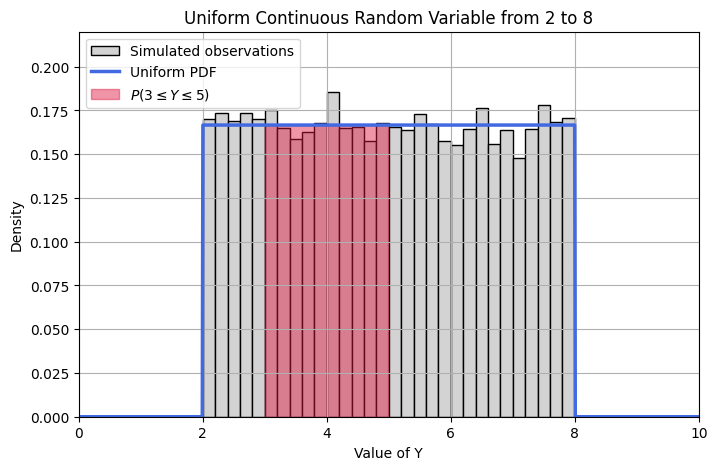

In [31]:
plt.figure(figsize=(8, 5))

plt.hist(continuous_samples, bins=30, density=True,
         color="lightgray", edgecolor="black",
         label="Simulated observations")

plt.plot(x_range, pdf_values, color="royalblue",
         linewidth=2.5, label="Uniform PDF")

interval_mask = (
    (x_range >= interval_lower) &
    (x_range <= interval_upper)
)

plt.fill_between(
    x_range[interval_mask],
    pdf_values[interval_mask],
    color="crimson",
    alpha=0.45,
    label=r"$P(3 \leq Y \leq 5)$"
)

plt.xlabel("Value of Y")
plt.ylabel("Density")
plt.title("Uniform Continuous Random Variable from 2 to 8")
plt.xlim(0, 10)
plt.ylim(0, 0.22)
plt.grid()
plt.legend()
plt.show()

### Section Reflection

The uniform random variable had equal density across the interval from 2 to 8. The probability P(3 <= Y <= 5) was found from the area under the PDF and equaled 1/3. Unlike a discrete random variable, a continuous random variable has probability zero at any single exact value, such as P(Y = 4) = 0.

## Conclusion / Reflection
Probability can be represented in different ways depending on the type of problem. In this homework, I used the probability axioms to understand a sample space, conditional probability to use additional information, a PMF for a discrete random variable, and a PDF for a continuous random variable.

Probability can be exact in some cases, estimated through simulation in other cases, and represented by areas when working with continuous random variables.